# Laboratorio 3

Integrantes del grupo
- Emmanuel Blanco - 202312743
- Juan David Guzmán - 202320890

In [17]:
# Importación de librerías necesarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, RobustScaler, PolynomialFeatures, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, validation_curve
from sklearn.utils import resample

## Carga de datos

In [3]:
training_data = pd.read_csv("./Datos_Laboratorio3.csv",sep=";")

print(f"Número de registros: {training_data.shape[0]}")
print(f"Número de variables: {training_data.shape[1]}")

training_data

Número de registros: 9698
Número de variables: 26


,Edad,Genero,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,...,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutrici�n
0,60,Masculino,73.7,1.61,28.43,Resistencia,Hipertension,Bajo,Avanzado,Vegano,...,0,0.0,0,0.0,0.92,182.1,16485,2.49,Medio,Sin plan
1,17,Femenino,121.0,1.97,31.18,Resistencia,Enfermedad corazon,Moderado,Principiante,Vegetariano,...,0,0.0,0,0.0,0.76,167.7,14256,2.04,Ninguno,Sin plan
2,43,Masculino,110.0,1.52,47.61,General,Ninguno,Bajo,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.34,104.9,3050,2.53,Bajo,Basico
3,49,Otro,73.6,1.96,19.16,General,Ninguno,Moderado,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.71,59.5,2264,3.36,Ninguno,Sin plan
4,53,Femenino,80.8,1.76,26.08,Resistencia,Hipertension,Alto,Principiante,Pescetariano,...,1,8.7,0,0.0,0.98,51.1,12774,1.90,Medio,Sin plan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9693,73,Femenino,139.0,1.92,37.71,Ganancia muscular,Ninguno,Moderado,Avanzado,Pescetariano,...,0,0.0,0,0.0,0.34,89.5,7507,4.34,Alto,Balanceado
9694,30,Masculino,62.2,1.81,18.99,Ganancia muscular,Ninguno,Moderado,Intermedio,No-Vegetariano,...,1,13.5,0,0.0,0.15,75.4,3817,3.17,Bajo,Balanceado
9695,63,Masculino,50.5,1.79,15.76,Resistencia,PCOS,Bajo,Intermedio,No-Vegetariano,...,0,0.0,0,0.0,0.75,141.7,12949,3.33,Ninguno,Sin plan
9696,60,Otro,122.2,1.73,40.83,General,Ninguno,Alto,Intermedio,Vegetariano,...,0,0.0,0,0.0,0.66,203.9,4772,2.64,Medio,Sin plan


## Exploración de datos

In [4]:
# Revisamos el tipo de dato de la variables

training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9698 entries, 0 to 9697
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Edad                     9698 non-null   int64  
 1   Genero                   9698 non-null   object 
 2   Peso                     9687 non-null   float64
 3   Altura                   9698 non-null   float64
 4   BMI                      9698 non-null   float64
 5   Objetivo                 9698 non-null   object 
 6   Condicion_salud          9698 non-null   object 
 7   Nivel_Actividad          9698 non-null   object 
 8   Nivel_experiencia        9698 non-null   object 
 9   Dieta_preferida          9698 non-null   object 
 10  Horas_sue�o              9698 non-null   float64
 11  Entrenamiento_preferido  9698 non-null   object 
 12  Cantidad_equipo          9698 non-null   int64  
 13  Tiempo_disponible        9698 non-null   int64  
 14  Tiene_alergia           

In [5]:
# Desplegamos la descripción de cada variable
training_data.describe()

,Edad,Peso,Altura,BMI,Horas_sue�o,Cantidad_equipo,Tiempo_disponible,Tiene_alergia,Problemas_digestivos,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua
count,9698.000000,9687.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000
mean,45.112601,92.622515,1.775047,30.131391,7.004382,2.988039,67.194061,0.201588,0.153846,0.227366,2.172252,0.285317,3.778841,0.500115,129.997360,9765.936482,2.748532
std,17.641045,27.383913,0.158754,10.605675,1.449454,2.018493,30.839475,0.401207,0.360820,0.419153,4.624756,0.451588,7.023263,0.289062,51.981874,4762.152079,1.015342
min,15.000000,45.000000,1.500000,10.930000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,40.000000,200.000000,1.000000
25%,30.000000,68.800000,1.640000,21.620000,5.800000,1.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,85.000000,5608.250000,1.860000
50%,45.000000,92.600000,1.780000,29.190000,7.000000,3.000000,67.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,129.950000,9718.000000,2.760000
75%,61.000000,116.500000,1.910000,37.060000,8.200000,5.000000,94.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.300000,0.750000,175.200000,13953.000000,3.620000
max,75.000000,140.000000,2.050000,62.090000,23.000000,6.000000,120.000000,1.000000,1.000000,1.000000,18.000000,1.000000,25.000000,1.000000,220.000000,17996.000000,4.500000


Nos podemos percatar de que a Peso le faltan 11 valores y en Horas_sueño el máximo es 23 horas lo cual es muy probablemente un error. Es importante notar que Tiene_alergia, Problemas_digestivos, Fumador y Alcohol son variables binarias, por lo que es posible que requieran menos procesamiento

In [6]:
# Revisamos los datos nulos

porcentajes_NaN = (training_data.isnull().sum()/(training_data.shape[0]*100)).sort_values(ascending=False)
info_faltante = pd.DataFrame({
    'Columna':porcentajes_NaN.index,
    'Total de datos faltantes':training_data.isnull().sum()[porcentajes_NaN.index].values,
    '%':porcentajes_NaN.values
})
info_faltante[info_faltante['Total de datos faltantes']>0]

,Columna,Total de datos faltantes,%
0,Peso,11,0.000011


Como lo habiamos visto antes en el describe Peso es la única variable a la que habría que imputar valores para completarla

Revisamos los formatos de la variables categóricas

In [7]:
training_data["Genero"].value_counts()

Genero
Femenino     4719
Masculino    4611
Otro          368
Name: count, dtype: int64

In [8]:
training_data["Condicion_salud"].value_counts()

Condicion_salud
Ninguno               6030
Hipertension           814
Lesion                 764
Asma                   745
Diabetes               511
Enfermedad corazon     497
PCOS                   337
Name: count, dtype: int64

In [9]:
training_data["Entrenamiento_preferido"].value_counts()

Entrenamiento_preferido
Funcional       1666
Hit             1620
Flexibilidad    1618
Cardio          1602
Fuerza          1601
Balance         1591
Name: count, dtype: int64

In [10]:
training_data["Objetivo"].value_counts()

Objetivo
Ganancia muscular    2757
Perdida grasa        2594
General              2220
Resistencia          2123
grasa                   4
Name: count, dtype: int64

En objetivo es probable que grasa y Perdida grasa sean un mismo objetivo pero representado de manera distinta, tendremos que unificar este formato

In [11]:
training_data["Nivel_Actividad"].value_counts()

Nivel_Actividad
Moderado    3594
Bajo        3326
Alto        2778
Name: count, dtype: int64

In [12]:
training_data["Nivel_experiencia"].value_counts()

Nivel_experiencia
Intermedio      4100
Principiante    3608
Avanzado        1990
Name: count, dtype: int64

In [13]:
training_data["Dieta_preferida"].value_counts()

Dieta_preferida
No-Vegetariano    2456
Vegano            2426
Pescetariano      2403
Vegetariano       2402
Animal              11
Name: count, dtype: int64

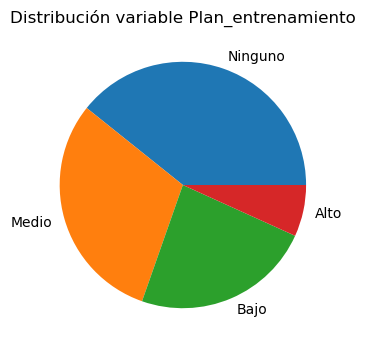

In [26]:
# Revisamos la variable objetivo Plan_entrenamiento
var1_count= training_data["Plan_entrenamiento"].value_counts()
plt.figure(figsize=(6,4))
plt.pie(var1_count,labels=var1_count.index)
plt.title("Distribución variable Plan_entrenamiento")
plt.show()


Nuestra tarea respecto al problema es mejorar la recomendación de planes de entrenamiento, en este caso vemos que hay 4 categorías de recomendación, donde la categoría de recomendación más común en los datos de ninguno.

Teniendo estos datos en cuenta, podríamos tomar dos alternativas para manejar esta categorías más fácilmente:
1. Podríamos unificar las categorias Bajo, Medio y Alto, como categorías que indican la recomendación de un plan de entrenamiento. De esta manera nuestro modelo ya solo tendrá que clasificar los datos frente a si recomendar o no un plan de entrenamiento
2. Se podrían unificar las categorías Bajo y Ninguno, y Medio y Alto, de esta manera el modelo haría una calsificación entre la recomendación de un plan que no cambia mucho la rutina de una persona o de un plan que cambia significativamente la rutina de una persona

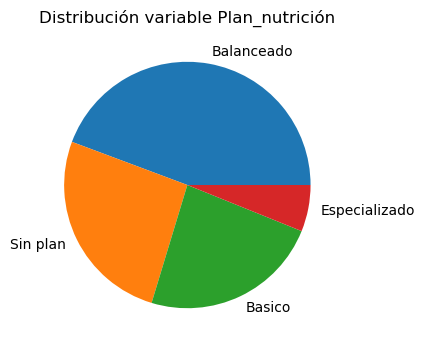

In [27]:
# Revisamos la variable objetivo Plan_nutrición

var2_count = training_data["Plan_nutrici�n"].value_counts()
plt.figure(figsize=(6,4))
plt.pie(var2_count,labels=var2_count.index)
plt.title("Distribución variable Plan_nutrición")
plt.show()

Respecto a esta segunda variable objetivo, podemos ver una situación bastante similar a la de la variable Plan_entrenamiento. Por lo tanto podemos proponer doa alternativas similares a las que se propusieron con respecto a la variable anteiror:
1. Unificar la categorías Basico, Balanceado y Especializado para que el modelo clasifique entre otorgar un plan de nutrición o no otorgarlo
2. Unificar las categorías Sin plan y Basico, y Balanceado y Especializado para clasificar entre si recomendar un plan sencillo (sin cambios o cambios básicos) o recomendar un plan más complejo (alimentación balanceada y especializada)

In [16]:
# Verificar registros duplicados
duplicados = training_data.duplicated().sum()
print(f"Número de registros duplicados:", duplicados)

Número de registros duplicados: 0


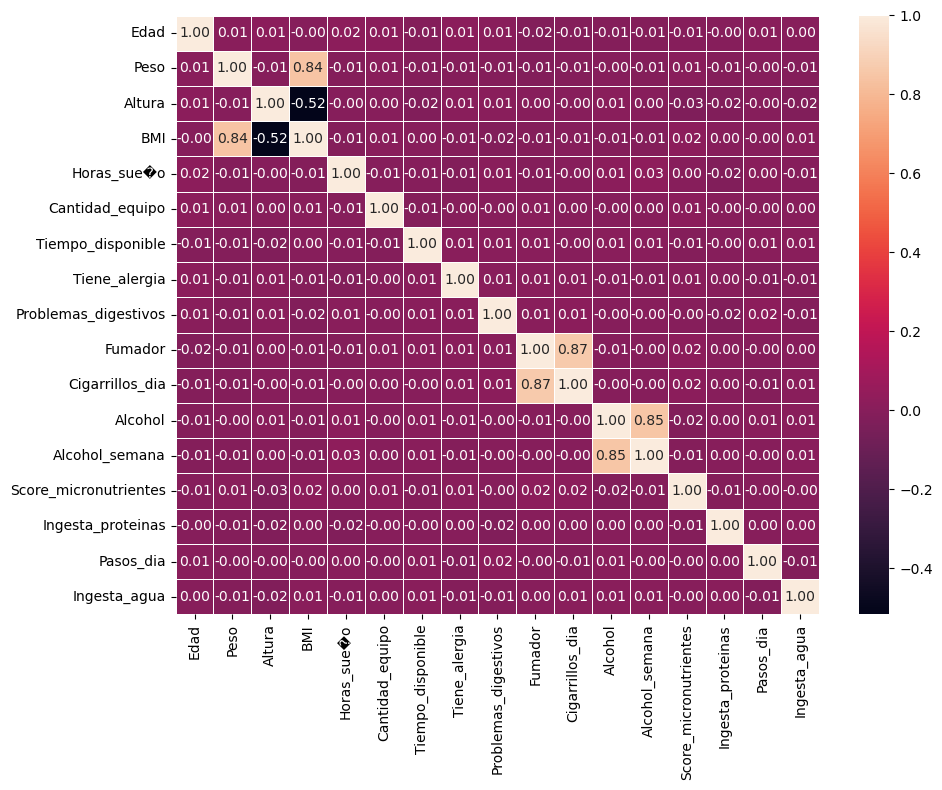

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(training_data.corr(numeric_only=True), annot=True, fmt=".2f", annot_kws={"size": 10},linewidths=0.5)
plt.tight_layout()
plt.show()

En el heatmap podemos ver que el índice de masa corporal tiene una correlación fuerte con la altura y el peso, por lo que lo mejor sería eliminar las variables altura y peso para la construcción de los modelos ya que están representadas a través de IMC (BMI).

Luego podemos ver que las variables Fumador y Cigarrillos_dia, y Alcohol y Alcohol_semana están fuertemente correlacionadas, esto se debe a que si en la columna Fumador/Alcohol hay un 0 en Cigarrillos_dia/Alcohol_semana habrá un cero (los que no son fumadores o consumen alcohol deberían tener un consumo de cero cigarrillos y alcohol al día), de contrario, si en la columna Fumador/Alcohol hay un 1, en Cigarrillos_dia/Alcohol_semana habrá un valor mayor a cero. Dicho esto, aún podemos distinguir entre consumidores de alcohol y tabaco sin las variables Fumador y Alcohol, por lo que estas variables deberían ser eliminadas.

## Limpieza y preparación de datos

## Modelos de regresión logística

## Modelos basados en árboles de decisión

## Comparación del rendimiento de los mejores modelos

## Identificación de las variables más relevantes en la predicción

## Video

## Generación de predicciones